In [1]:
import sys
sys.path.insert(0, "..")

import joblib

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from loguru import logger

pd.set_option("display.max_columns", None)

In [2]:
from src.evaluation.metrics import build_predictions_report

In [3]:
def plot_barh_by_model(results_df, x, y="model", hue=None, title="", figsize=(8, 6)):
    """Barplot horizontal genérico para comparar modelos por una métrica."""
    df_sorted = results_df.sort_values(x, ascending=True)
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(df_sorted, x=x, y=y, hue=hue, order=df_sorted[y], ax=ax)
    ax.set_title(title, loc="left", pad=20)
    ax.set_xlabel("")
    ax.set_ylabel("")
    sns.despine()
    if hue:
        ax.legend(title=hue, loc="upper right")
    plt.tight_layout()
    plt.show()

In [4]:
LEVEL = 'level_12_daily_item_store'
TARGET = 'sales'

In [5]:
import joblib

artifact_path = f"../artifacts/models/{LEVEL}_{TARGET}_artifact.pkl"
artifact = joblib.load(artifact_path)

model = artifact["model"]
X_test, y_test = artifact["X_test"], artifact["y_test"]
FEATURES = artifact["features"]
feature_importance = artifact["feature_importance"]
results_df = artifact["results_df"]

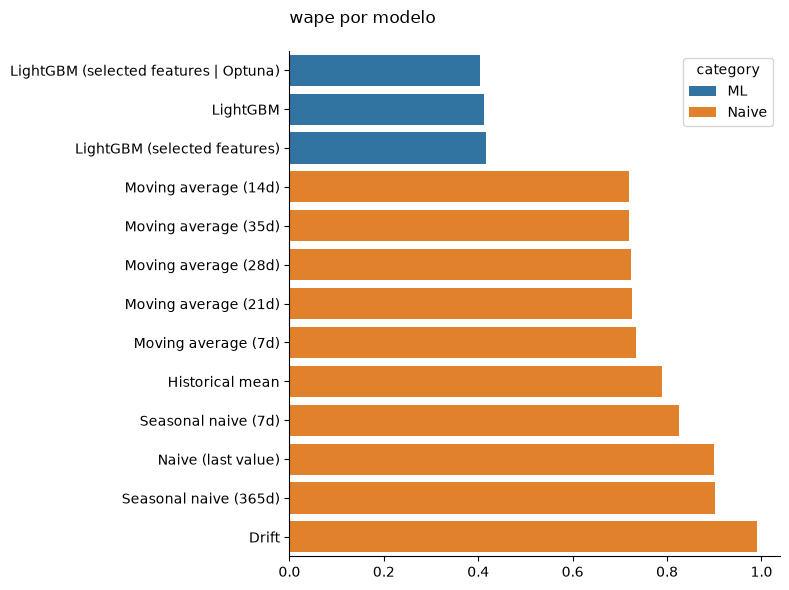

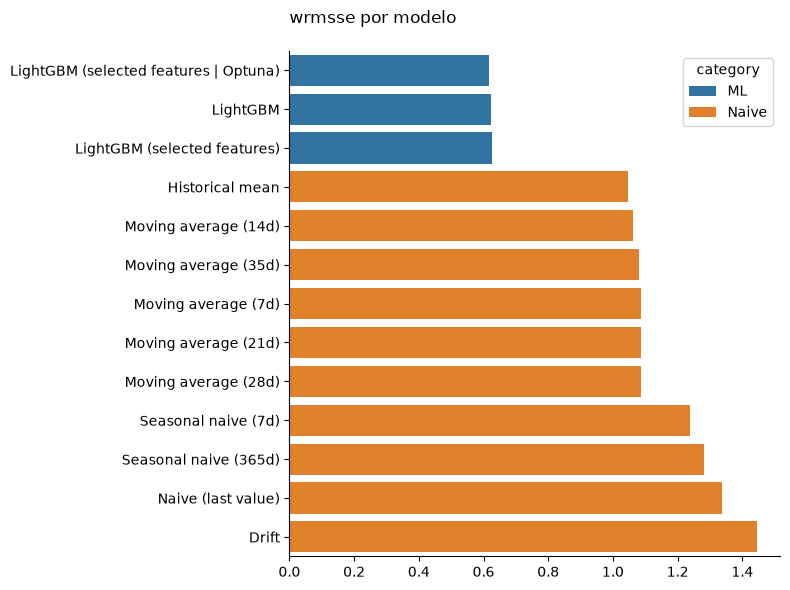

In [6]:
#['wape', 'wrmsse', 'mae', 'rmse', 'mape', 'smape', 'bias', 'rmsle', 'tracking_signal', 'spec', 'mase', 'fit_time']:
for col in ['wape', 'wrmsse',]:
    plot_barh_by_model(results_df, hue="category", x=col, y="model", title=f"{col} por modelo")

## Explicación modelo

In [18]:
import shap

explainer = shap.TreeExplainer(model)

X_shap = X_test.sample(n=min(30_000, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_shap)

In [19]:
shap_df = pd.DataFrame(shap_values, columns=X_shap.columns, index=X_shap.index)

importance_df = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

print(importance_df)

                           feature  mean_abs_shap
3                     price_vs_max      12.369470
1                     price_change       0.634567
7                             lag7       0.381222
4                             lag1       0.237756
8  rolling_mean_lag7_window_size14       0.220302
0                          item_id       0.156988
5                             lag2       0.141455
6                             lag3       0.116104
2                        dayofweek       0.037776


### Importancia global de features

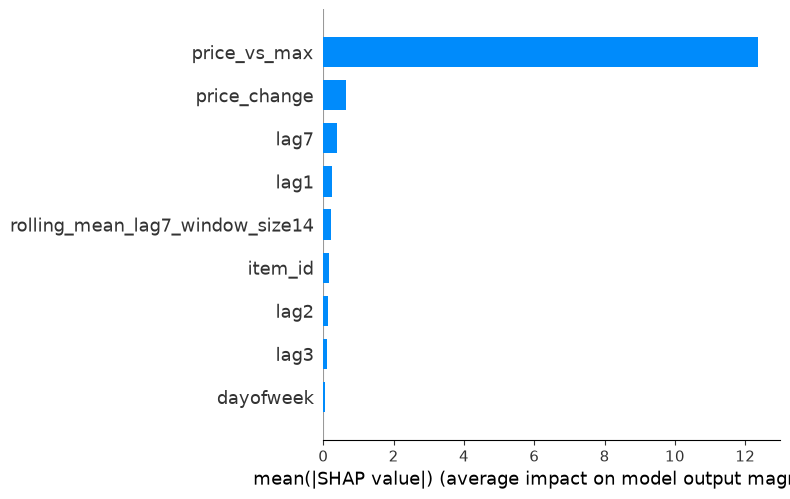

In [20]:
shap.summary_plot(shap_values, X_shap, plot_type="bar")

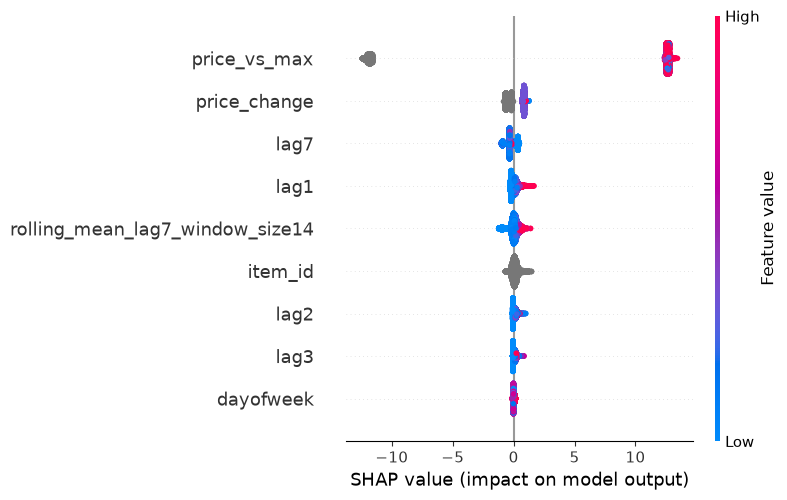

In [21]:
shap.summary_plot(shap_values, X_shap)

### Dependencia por feature

Feature más importante: price_vs_max


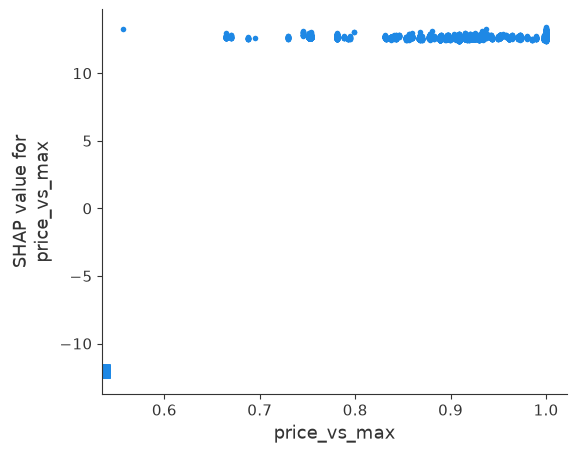

In [22]:
top_feature = X_shap.columns[np.argsort(-np.abs(shap_values).mean(axis=0))[0]]
print(f"Feature más importante: {top_feature}")

shap.dependence_plot(top_feature, shap_values, X_shap, interaction_index=None)

In [23]:
metrics_test_final, df_pred = build_predictions_report(artifact['train'], artifact['test'], y_test, model.predict(X_test), target_col=artifact['target'])

print(f"Test WAPE: {metrics_test_final['wape']:.2%}")
print(f"Test WRMSSE: {metrics_test_final['wrmsse']:.4f}")

Test WAPE: 40.64%
Test WRMSSE: 0.5442


# Predicciones

In [24]:
from src.evaluation import analizar_prediccion as _analizar_prediccion

def analizar_prediccion(agg_id, test=artifact['test'], target=artifact['target'],
                         explainer=explainer, date=None, max_display=10):
    return _analizar_prediccion(
        test, X_test, df_pred, target, agg_id,
        date=date, max_display=max_display, explainer=explainer,
    )

In [25]:
from src.evaluation.metrics import build_series_metrics

df_metrics = build_series_metrics(artifact['train'], df_pred, target_col=artifact['target'], weight_level=["date"])
df_metrics.head(10)

/home/njimenez/Workspace/magister/forecast-tfm/notebooks/../src/evaluation/metrics.py:11: RuntimeWarning: invalid value encountered in scalar divide
  return np.abs(y_true - y_pred).sum() / np.abs(y_true).sum()
/home/njimenez/Workspace/magister/forecast-tfm/notebooks/../src/evaluation/metrics.py:16: RuntimeWarning: invalid value encountered in scalar divide
  return (y_pred - y_true).sum() / np.abs(y_true).sum()


,n_days,n_days_with_sales,sales,y_pred,error,abs_error,gross_sales,gross_sales_pct,wape,bias,rmsle,tracking_signal,wrmsse,mase,spec
agg_id,,,,,,,,,,,,,,,
FOODS_3_FOODS_FOODS_3_120_CA_3_CA,28,28,1617.0,1801.0,-184.0,378.0,8052.660156,0.041328,0.233766,0.113791,0.361856,-13.629630,0.521823,0.821012,26.732143
FOODS_3_FOODS_FOODS_3_090_CA_3_CA,28,28,3357.0,3605.0,-248.0,638.0,5371.200195,0.027566,0.190051,0.073875,0.239058,-10.884013,0.372583,0.530570,25.973214
FOODS_3_FOODS_FOODS_3_586_CA_3_CA,28,28,1883.0,1911.0,-28.0,234.0,3163.439941,0.016236,0.124270,0.014870,0.143339,-3.350427,0.603235,0.592181,5.080357
FOODS_3_FOODS_FOODS_3_202_CA_3_CA,28,28,560.0,620.0,-60.0,148.0,2620.800049,0.013451,0.264286,0.107143,0.293663,-11.351351,0.486585,0.578207,25.366071
FOODS_3_FOODS_FOODS_3_252_CA_3_CA,28,28,1405.0,1347.0,58.0,284.0,2219.899902,0.011393,0.202135,-0.041281,0.234015,5.718310,0.870945,0.886698,22.767857
FOODS_3_FOODS_FOODS_3_587_CA_3_CA,28,28,876.0,923.0,-47.0,161.0,2172.479980,0.011150,0.183790,0.053653,0.246388,-8.173913,0.548886,0.541242,7.660714
FOODS_3_FOODS_FOODS_3_702_CA_3_CA,28,28,696.0,595.0,101.0,193.0,2088.000000,0.010716,0.277299,-0.145115,0.372239,14.652850,1.332857,1.341796,117.937500
FOODS_3_FOODS_FOODS_3_511_CA_3_CA,28,28,290.0,314.0,-24.0,86.0,2024.199951,0.010389,0.296552,0.082759,0.429476,-7.813953,0.674583,1.101963,9.366071
FOODS_3_FOODS_FOODS_3_444_CA_3_CA,28,19,281.0,292.0,-11.0,71.0,1961.380005,0.010066,0.252669,0.039146,0.232552,-4.338028,0.882435,0.767343,3.169643


In [26]:
df_metrics.head(10)

,n_days,n_days_with_sales,sales,y_pred,error,abs_error,gross_sales,gross_sales_pct,wape,bias,rmsle,tracking_signal,wrmsse,mase,spec
agg_id,,,,,,,,,,,,,,,
FOODS_3_FOODS_FOODS_3_120_CA_3_CA,28,28,1617.0,1801.0,-184.0,378.0,8052.660156,0.041328,0.233766,0.113791,0.361856,-13.629630,0.521823,0.821012,26.732143
FOODS_3_FOODS_FOODS_3_090_CA_3_CA,28,28,3357.0,3605.0,-248.0,638.0,5371.200195,0.027566,0.190051,0.073875,0.239058,-10.884013,0.372583,0.530570,25.973214
FOODS_3_FOODS_FOODS_3_586_CA_3_CA,28,28,1883.0,1911.0,-28.0,234.0,3163.439941,0.016236,0.124270,0.014870,0.143339,-3.350427,0.603235,0.592181,5.080357
FOODS_3_FOODS_FOODS_3_202_CA_3_CA,28,28,560.0,620.0,-60.0,148.0,2620.800049,0.013451,0.264286,0.107143,0.293663,-11.351351,0.486585,0.578207,25.366071
FOODS_3_FOODS_FOODS_3_252_CA_3_CA,28,28,1405.0,1347.0,58.0,284.0,2219.899902,0.011393,0.202135,-0.041281,0.234015,5.718310,0.870945,0.886698,22.767857
FOODS_3_FOODS_FOODS_3_587_CA_3_CA,28,28,876.0,923.0,-47.0,161.0,2172.479980,0.011150,0.183790,0.053653,0.246388,-8.173913,0.548886,0.541242,7.660714
FOODS_3_FOODS_FOODS_3_702_CA_3_CA,28,28,696.0,595.0,101.0,193.0,2088.000000,0.010716,0.277299,-0.145115,0.372239,14.652850,1.332857,1.341796,117.937500
FOODS_3_FOODS_FOODS_3_511_CA_3_CA,28,28,290.0,314.0,-24.0,86.0,2024.199951,0.010389,0.296552,0.082759,0.429476,-7.813953,0.674583,1.101963,9.366071
FOODS_3_FOODS_FOODS_3_444_CA_3_CA,28,19,281.0,292.0,-11.0,71.0,1961.380005,0.010066,0.252669,0.039146,0.232552,-4.338028,0.882435,0.767343,3.169643


In [29]:
df_pred.query('agg_id == "FOODS_3_FOODS_FOODS_3_120_CA_3_CA"').nlargest(10, 'wape')

,agg_id,date,sales,gross_sales,y_pred,error,abs_error,wape,bias
230971,FOODS_3_FOODS_FOODS_3_120_CA_3_CA,2016-05-15,20.0,99.599998,75.0,-55.0,55.0,2.750000,2.750000
230978,FOODS_3_FOODS_FOODS_3_120_CA_3_CA,2016-05-22,33.0,164.339996,67.0,-34.0,34.0,1.030303,1.030303
230968,FOODS_3_FOODS_FOODS_3_120_CA_3_CA,2016-05-12,31.0,154.380005,60.0,-29.0,29.0,0.935484,0.935484
230964,FOODS_3_FOODS_FOODS_3_120_CA_3_CA,2016-05-08,48.0,239.039993,81.0,-33.0,33.0,0.687500,0.687500
230972,FOODS_3_FOODS_FOODS_3_120_CA_3_CA,2016-05-16,30.0,149.399994,45.0,-15.0,15.0,0.500000,0.500000
230954,FOODS_3_FOODS_FOODS_3_120_CA_3_CA,2016-04-28,46.0,229.080002,66.0,-20.0,20.0,0.434783,0.434783
230976,FOODS_3_FOODS_FOODS_3_120_CA_3_CA,2016-05-20,41.0,204.179993,58.0,-17.0,17.0,0.414634,0.414634
230961,FOODS_3_FOODS_FOODS_3_120_CA_3_CA,2016-05-05,52.0,258.959991,66.0,-14.0,14.0,0.269231,0.269231
230973,FOODS_3_FOODS_FOODS_3_120_CA_3_CA,2016-05-17,57.0,283.859985,42.0,15.0,15.0,0.263158,-0.263158
230970,FOODS_3_FOODS_FOODS_3_120_CA_3_CA,2016-05-14,79.0,393.420013,62.0,17.0,17.0,0.215190,-0.215190


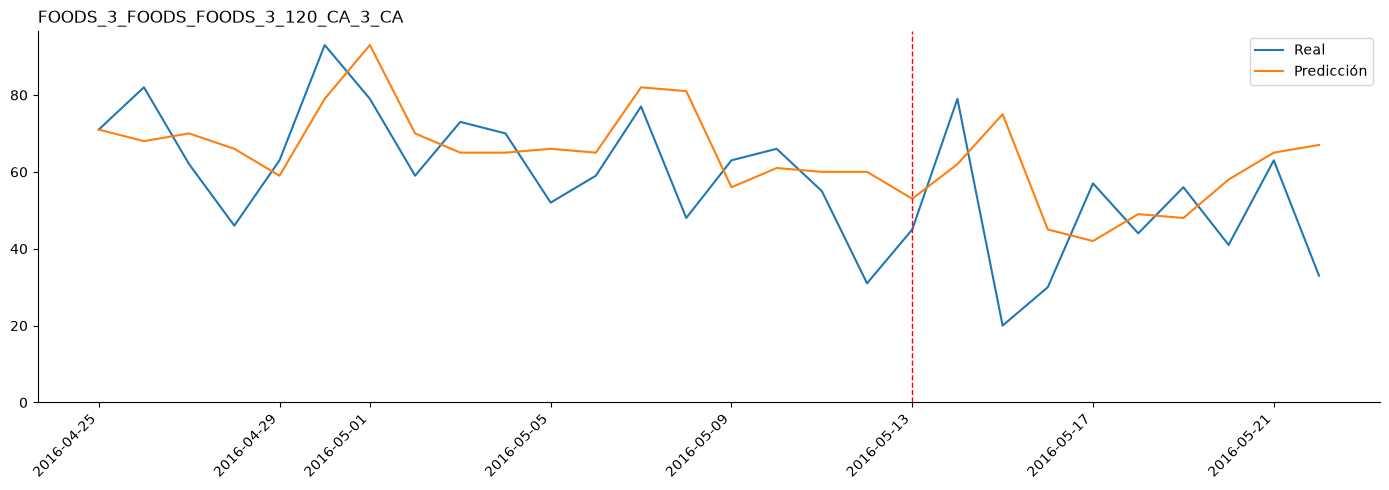

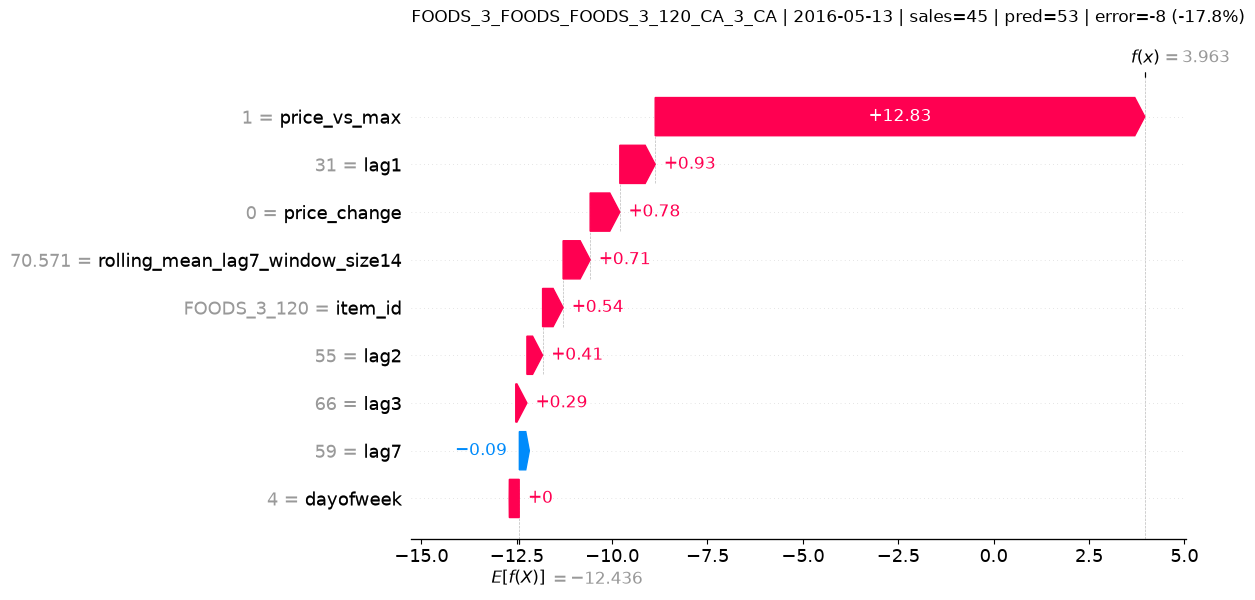

In [30]:
analizar_prediccion(agg_id='FOODS_3_FOODS_FOODS_3_120_CA_3_CA', date='2016-05-13' )